# **✈️ Jet Engine Predictive Maintenance (RUL)**
This dataset contains comprehensive prognostic data for turbofan engine degradation simulation, generated using NASA's Commercial Modular Aero-Propulsion System Simulation (C-MAPSS). The dataset is part of NASA's Prognostics Data Repository, which focuses exclusively on prognostic datasets that can be used for developing predictive maintenance algorithms

### **Key Features**
- Simulation Framework: Generated using the Commercial Modular Aero-Propulsion System Simulation (C-MAPSS)
- Multiple Scenarios: Four different datasets simulated under different combinations of operational conditions and fault modes
- Sensor Data: Multiple sensor channels that characterize fault evolution over time
- Time Series Format: Data progresses from nominal operational state to failure state

## **Objective**
Predict the exact number of remaining operational flight cycles before an aircraft engine requires overhaul or risks mechanical failure.

**The Math & Architecture:** This is formulated as a sequence-to-many regression problem. You feed rolling time-series windows of sensor data into an **LSTM (Long Short-Term Memory)** network or a **1D-CNN (Temporal Convolutional Network)**. The model learns features across a sliding historical cycle window ($T$) to output a continuous target variable:    
    $$
    RUL_t = \max(0, \text{Max\_Cycle}_i - t)
    $$

To improve model stability early in an engine's life cycle, a piecewise linear RUL target function is typically applied, capping maximum healthy RUL at a fixed threshold (e.g., $125$ cycles).

## **Dataset Overview**

| Column Index | Column Name | Type | Unit / Description |
| --- | --- | --- | --- |
| **1** | `unit_nr` | Integer | Engine ID / Unit Number |
| **2** | `time_cycles` | Integer | Operational time cycle / Flight count |
| **3** | `setting_1` | Float | Operational Setting 1 (Altitude) |
| **4** | `setting_2` | Float | Operational Setting 2 (Mach Number) |
| **5** | `setting_3` | Float | Operational Setting 3 (Throttle Resolver Angle - TRA) |
| **6** | `s1` (`T2`) | Float | Total temperature at fan inlet (°R) |
| **7** | `s2` (`T24`) | Float | Total temperature at LPC outlet (°R) |
| **8** | `s3` (`T30`) | Float | Total temperature at HPC outlet (°R) |
| **9** | `s4` (`T50`) | Float | Total temperature at LPT outlet (°R) |
| **10** | `s5` (`P2`) | Float | Pressure at fan inlet (psia) |
| **11** | `s6` (`P15`) | Float | Total pressure in bypass-duct (psia) |
| **12** | `s7` (`P30`) | Float | Total pressure at HPC outlet (psia) |
| **13** | `s8` (`Nf`) | Float | Physical fan speed (rpm) |
| **14** | `s9` (`Nc`) | Float | Physical core speed (rpm) |
| **15** | `s10` (`epr`) | Float | Engine pressure ratio ($P_{50}/P_2$) |
| **16** | `s11` (`Ps30`) | Float | Static pressure at HPC outlet (psia) |
| **17** | `s12` (`phi`) | Float | Ratio of fuel flow to $P_{s30}$ (pps/psi) |
| **18** | `s13` (`NRf`) | Float | Corrected fan speed (rpm) |
| **19** | `s14` (`NRc`) | Float | Corrected core speed (rpm) |
| **20** | `s15` (`BPR`) | Float | Bypass ratio |
| **21** | `s16` (`farB`) | Float | Burner fuel-air ratio |
| **22** | `s17` (`htBleed`) | Float | Bleed enthalpy |
| **23** | `s18` (`Nf_dmd`) | Float | Demanded fan speed (rpm) |
| **24** | `s19` (`PCNfR_dmd`) | Float | Demanded corrected fan speed (rpm) |
| **25** | `s20` (`W31`) | Float | HPT coolant bleed (lbm/s) |
| **26** | `s21` (`W32`) | Float | LPT coolant bleed (lbm/s) |

#### Quick Sub-dataset Summary (Operational Variations)

Depending on which training file you are looking at (`train_FD001` through `train_FD004`), the conditions and fault modes vary :

| Dataset | Training Engines | Test Engines | Operating Conditions | Fault Modes Present |
| --- | --- | --- | --- | --- |
| **FD001** | 100 | 100 | 1 (Sea Level) | 1 (HPC Degradation) |
| **FD002** | 260 | 259 | 6 | 1 (HPC Degradation) |
| **FD003** | 100 | 100 | 1 (Sea Level) | 2 (HPC Degradation, Fan Degradation) |
| **FD004** | 248 | 249 | 6 | 2 (HPC Degradation, Fan Degradation) |

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/RUL_FD002.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/test_FD003.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/Damage Propagation Modeling.pdf
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/readme.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/train_FD003.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/test_FD004.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/train_FD004.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/test_FD002.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/train_FD001.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/train_FD002.txt
/kaggle/input/datasets/bishals098/nasa-turbofan-engine

In [2]:
# Define column names as per the dataset structure
COLS = ['unit','cycle','os1','os2','os3'] + [f's{i}' for i in range(1, 22)]
cols = ["unit", "cycle", "setting1", "setting2", "setting3"] + [f"s{i}" for i in range(1, 22)]
data = pd.read_csv("/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/train_FD001.txt", sep=r"\s+", header=None, names=cols)

def load_data(path):
    return pd.read_csv(path, sep=r'\s+', header=None,
                       usecols=range(26), names=COLS, engine='python')
 
BASE  = '/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/'
train = load_data(BASE + 'train_FD001.txt')
test  = load_data(BASE + 'test_FD001.txt')
rul   = pd.read_csv(BASE + 'RUL_FD001.txt', header=None, names=['rul'])
 
print(f"Train: {train.shape}  |  Test: {test.shape}  |  RUL entries: {len(rul)}")
print(f"Train engines: {train['unit'].nunique()}  |  Test engines: {test['unit'].nunique()}")

Train: (20631, 26)  |  Test: (13096, 26)  |  RUL entries: 100
Train engines: 100  |  Test engines: 100


In [3]:
data.head()

,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## **Exploratory Data Analysis**

Number of engines: 100


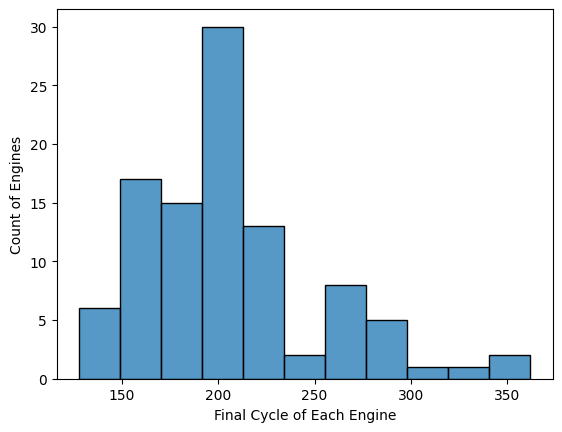

In [4]:
engine_lives = data.groupby('unit')['cycle'].max()
sns.histplot(data=data, x=engine_lives)

print("Number of engines:", engine_lives.count())

plt.xlabel("Final Cycle of Each Engine")
plt.ylabel("Count of Engines")
plt.show()

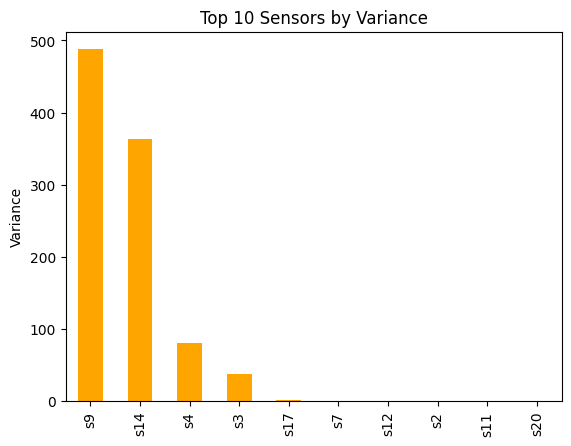

In [5]:
# Sensor columns
sensor_cols = [c for c in data.columns if c.startswith("s")]

# Variance per sensor
var_series = data[sensor_cols].var().sort_values(ascending=False)

# Bar plot for top 10 sensors by variance
var_series.head(10).plot(kind='bar', color='orange', title="Top 10 Sensors by Variance")
plt.ylabel("Variance")
plt.show()

## **1. Problem Formulation: Piecewise Linear Target**

In the training sets, engines run from healthy operation until complete failure. The raw ground-truth RUL for unit $i$ at time cycle $t$ is:

$$\text{RUL}_{i, t} = \text{Max\_Cycle}_i - t$$

### **Capping RUL (Early-life Clipping)**

In practice, an engine operating during its first 30 cycles is effectively "brand new"—degradation hasn't started, and sensor noise makes learning early-life degradation impossible.

To resolve this, standard C-MAPSS modeling applies **piecewise clipping** (typically capped at $RUL_{max} = 125$ to $130$ cycles):

$$\text{RUL}_{i, t} = \min\left(RUL_{max}, \text{Max\_Cycle}_i - t\right)$$

This forces the model to predict a constant health state until degradation becomes statistically observable.


## **2. Feature Engineering & Preprocessing**

### A. Dropping Non-Informative Channels

In single-condition subsets (like `FD001` or `FD003`), several sensors maintain constant values or variance near zero (e.g., $s1$, $s5$, $s10$, $s16$, $s18$, $s19$). Calculate standard deviation across groups and drop flat features:

$$\sigma_{s_k} \approx 0 \implies \text{Drop Column}$$

### B. Normalization

Because sensor values use completely different scales (e.g., temperatures in Hundreds of °R vs. pressure ratios $\approx 1.0$), scale per feature using **MinMaxScaler** or **StandardScaler**, keeping engine IDs grouped separately.

### C. Sequence Windowing (Sliding Window)

Instead of feeding individual rows, slice sensor data into historical rolling windows of sequence length $W$ (commonly $W = 30$ or $50$ cycles).

* **Input shape per sample:** $(W, F)$ where $F$ is the count of active sensor/setting features.
* **Target output:** $RUL_{t}$ corresponding to the final cycle of that window.

## **3. Evaluation Strategy on Test Datasets**

The Kaggle dataset splits test sequences differently than training sequences:

* **`test_FD00X.txt`**: Engine time series are truncated at a random point prior to failure.
* **`RUL_FD00X.txt`**: Contains a single ground-truth scalar for each engine's true remaining cycle count at the end of its test file.

### Validation Pipeline:

1. Pass each engine's **last $W$ cycles** from `test_FD00X.txt` into the model.
2. Compare predicted output $\hat{y}_i$ against the actual value in `RUL_FD00X.txt`.
3. Primary Metrics: **RMSE** and the asymmetric **NASA Scoring Function** (which penalizes late predictions heavier than early ones to prevent late maintenance decisions):

$$S = \sum_{i=1}^{N} \left( e^{\frac{d_i}{13}} - 1 \right) \quad \text{for } d_i < 0 \quad (\text{Late prediction})$$

$$S = \sum_{i=1}^{N} \left( e^{-\frac{d_i}{10}} - 1 \right) \quad \text{for } d_i \ge 0 \quad (\text{Early prediction})$$

Where $d_i = \hat{\text{RUL}}_i - \text{RUL}_i$.


In [6]:
import torch
import torch.nn as nn
import tensorflow as tf
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set clean white grid theme for matplotlib/seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'font.size': 12
})

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [7]:
KAGGLE_PATH = "/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation"
COLUMNS = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's{i}' for i in range(1, 22)]

def load_data(dataset_dir, max_rul=125):
    train_path = f"{dataset_dir}/train_FD001.txt"
    test_path = f"{dataset_dir}/test_FD001.txt"
    rul_path = f"{dataset_dir}/RUL_FD001.txt"
    
    train_df = pd.read_csv(train_path, sep=r'\s+', header=None, names=COLUMNS)
    test_df = pd.read_csv(test_path, sep=r'\s+', header=None, names=COLUMNS)
    rul_df = pd.read_csv(rul_path, sep=r'\s+', header=None, names=['RUL'])

    # --- Feature Engineering: Target Creation (Piecewise Linear RUL) ---
    max_cycles = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycles.rename(columns={'time_cycles': 'max_cycle'}, inplace=True)
    train_df = train_df.merge(max_cycles, on='unit_nr', how='left')
    
    train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']
    train_df.drop(columns=['max_cycle'], inplace=True)
    train_df['RUL'] = train_df['RUL'].clip(upper=max_rul)

    # Drop low variance / flat sensor columns
    drop_sensors = ['s1', 's5', 's10', 's16', 's18', 's19', 'setting_3']
    features = [c for c in COLUMNS if c not in ['unit_nr', 'time_cycles'] + drop_sensors]

    # Normalize features
    scaler = MinMaxScaler()
    train_df[features] = scaler.fit_transform(train_df[features])
    test_df[features] = scaler.transform(test_df[features])

    return train_df, test_df, rul_df, features

def create_sequences(df, sequence_length, features, target_col='RUL', is_test=False):
    sequences, targets = [], []
    
    for unit in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == unit]
        data_matrix = unit_df[features].values
        
        if not is_test:
            target_matrix = unit_df[target_col].values
            for i in range(len(unit_df) - sequence_length + 1):
                sequences.append(data_matrix[i : i + sequence_length])
                targets.append(target_matrix[i + sequence_length - 1])
        else:
            if len(unit_df) >= sequence_length:
                sequences.append(data_matrix[-sequence_length:])
            else:
                pad = np.zeros((sequence_length - len(unit_df), data_matrix.shape[1]))
                sequences.append(np.vstack((pad, data_matrix)))
                
    return np.array(sequences, dtype=np.float32), np.array(targets, dtype=np.float32)

In [8]:
class CMAPSSDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = torch.tensor(sequences, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

class CNNLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1):
        super(CNNLSTMModel, self).__init__()
        
        self.conv1d = nn.Sequential(
            nn.Conv1d(in_channels=input_dim, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        
        self.lstm = nn.LSTM(
            input_size=64, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=0.1 if num_layers > 1 else 0
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1d(x)
        x = x.permute(0, 2, 1)
        
        out, _ = self.lstm(x)
        last_step_out = out[:, -1, :] 
        prediction = self.fc(last_step_out)
        return prediction.squeeze(-1)

In [9]:
SEQUENCE_LENGTH = 30
MAX_RUL = 125
BATCH_SIZE = 64
EPOCHS = 15
LR = 0.001

# Load data directly using your Kaggle input path
train_df, test_df, RUL_df, feature_cols = load_data(
    dataset_dir=KAGGLE_PATH,
    max_rul=MAX_RUL
)

X_train, y_train = create_sequences(train_df, SEQUENCE_LENGTH, feature_cols, is_test=False)
X_test, _ = create_sequences(test_df, SEQUENCE_LENGTH, feature_cols, is_test=True)
y_test = RUL_df['RUL'].clip(upper=MAX_RUL).values.astype(np.float32)

train_loader = DataLoader(CMAPSSDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(CMAPSSDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNLSTMModel(input_dim=len(feature_cols)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Interactive progress bar across epochs
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    
    # Initialize the native Keras Progbar
    pbar = tf.keras.utils.Progbar(
        target=len(train_loader), 
        stateful_metrics=['loss', 'rmse']
    )
    
    model.train()
    total_loss = 0
    
    for idx, (seqs, targets) in enumerate(train_loader):
        seqs, targets = seqs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(seqs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        # Calculate running batch metrics
        current_loss = loss.item()
        rmse_val = np.sqrt(current_loss)
        
        # Update progress bar step by step
        pbar.update(idx + 1, values=[('loss', current_loss), ('rmse', rmse_val)])

Epoch 1/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 65.9471 - rmse: 8.1208  
Epoch 2/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 349.8133 - rmse: 18.7033
Epoch 3/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 110.8249 - rmse: 10.5273
Epoch 4/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 216.6417 - rmse: 14.7188
Epoch 5/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 387.8908 - rmse: 19.6949
Epoch 6/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 145.8505 - rmse: 12.0769
Epoch 7/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 688.0193 - rmse: 26.2301
Epoch 8/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 197.3135 - rmse: 14.0468
Epoch 9/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 156.2767 - rmse: 12.5011
Epoch 10/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 33.7706 - rmse: 5.8112  
Epoch 11/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 479.8858 - rmse: 21.9063
Epoch 12/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/ste

In [10]:
model.eval()
predictions = []
with torch.no_grad():
    for seqs, _ in test_loader:
        seqs = seqs.to(device)
        preds = model(seqs)
        predictions.extend(preds.cpu().numpy())

y_pred = np.array(predictions)
y_true = y_test

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
errors = y_pred - y_true

print(f"--- Final Test Performance ---")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE:  {mae:.2f}")

--- Final Test Performance ---
Test RMSE: 16.62
Test MAE:  11.92


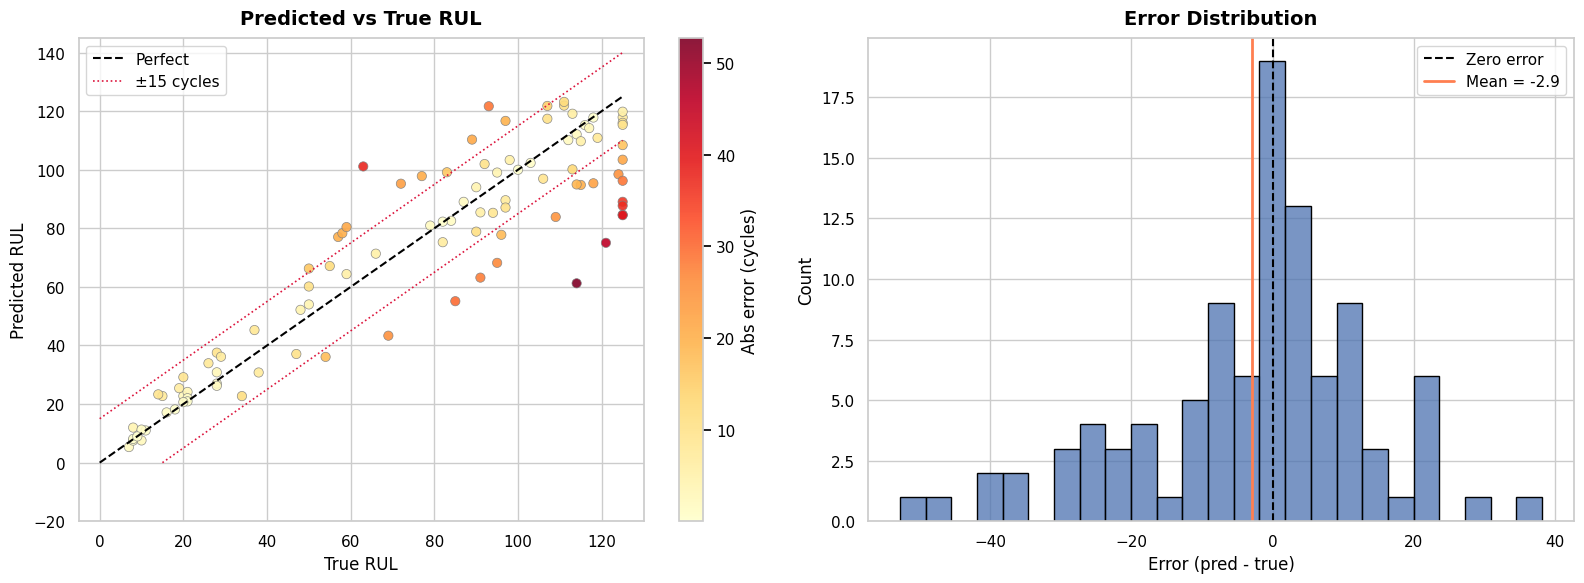

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

abs_errors = np.abs(errors)
scatter = axes[0].scatter(
    y_true, 
    y_pred, 
    c=abs_errors, 
    cmap='YlOrRd', 
    edgecolor='gray', 
    linewidth=0.5, 
    s=45, 
    alpha=0.9
)
cbar = fig.colorbar(scatter, ax=axes[0])
cbar.set_label('Abs error (cycles)')

axes[0].plot([0, MAX_RUL], [0, MAX_RUL], color='black', linestyle='--', linewidth=1.5, label='Perfect')
axes[0].plot([0, MAX_RUL], [15, MAX_RUL + 15], color='crimson', linestyle=':', linewidth=1.2, label='±15 cycles')
axes[0].plot([15, MAX_RUL], [0, MAX_RUL - 15], color='crimson', linestyle=':', linewidth=1.2)

axes[0].set_title('Predicted vs True RUL', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('True RUL', fontsize=12)
axes[0].set_ylabel('Predicted RUL', fontsize=12)
axes[0].set_xlim(-5, MAX_RUL + 5)
axes[0].set_ylim(-20, MAX_RUL + 20)
axes[0].legend(loc='upper left', frameon=True)

sns.histplot(
    errors, 
    bins=25, 
    color='#4C72B0', 
    edgecolor='black', 
    ax=axes[1], 
    kde=False
)

mean_error = np.mean(errors)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(mean_error, color='coral', linestyle='-', linewidth=2, label=f'Mean = {mean_error:.1f}')

axes[1].set_title('Error Distribution', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Error (pred - true)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()